In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv("matches.csv")  # descarga del dataset
print(df.shape)
print(df.columns.tolist())
df.head()

(3800, 28)
['date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain', 'formation', 'opp formation', 'referee', 'match report', 'notes', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'team', 'season']


,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,opp formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,team,season
0,2020-09-12,12:30,Premier League,Matchweek 1,Sat,Away,W,3,0,Fulham,1.9,0.1,54.0,NaN,Pierre-Emerick Aubameyang,3-4-3,4-2-3-1,Chris Kavanagh,Match Report,NaN,13.0,5.0,14.1,2.0,0,0,Arsenal,2021
1,2020-09-19,20:00,Premier League,Matchweek 2,Sat,Home,W,2,1,West Ham,1.1,2.0,62.0,NaN,Pierre-Emerick Aubameyang,3-4-3,5-4-1,Michael Oliver,Match Report,NaN,7.0,3.0,14.8,0.0,0,0,Arsenal,2021
2,2020-09-28,20:00,Premier League,Matchweek 3,Mon,Away,L,1,3,Liverpool,1.3,2.7,34.0,NaN,Pierre-Emerick Aubameyang,3-4-3,4-3-3,Craig Pawson,Match Report,NaN,4.0,3.0,15.0,0.0,0,0,Arsenal,2021
3,2020-10-04,14:00,Premier League,Matchweek 4,Sun,Home,W,2,1,Sheffield Utd,0.6,0.2,64.0,NaN,Pierre-Emerick Aubameyang,4-3-3,3-5-2,Lee Mason,Match Report,NaN,6.0,5.0,16.3,0.0,0,0,Arsenal,2021
4,2020-10-17,17:30,Premier League,Matchweek 5,Sat,Away,L,0,1,Manchester City,0.9,1.3,42.0,NaN,Pierre-Emerick Aubameyang,4-3-3,3-1-4-2,Chris Kavanagh,Match Report,NaN,11.0,3.0,18.4,2.0,0,0,Arsenal,2021


## Distribución de clases (W/D/L)

result
W    1467
L    1467
D     866
Name: count, dtype: int64
team
Arsenal                     190
Aston Villa                 190
Brighton And Hove Albion    190
Chelsea                     190
Crystal Palace              190
Name: count, dtype: int64
season
2021    760
2022    760
2023    760
2024    760
2025    760
Name: count, dtype: int64


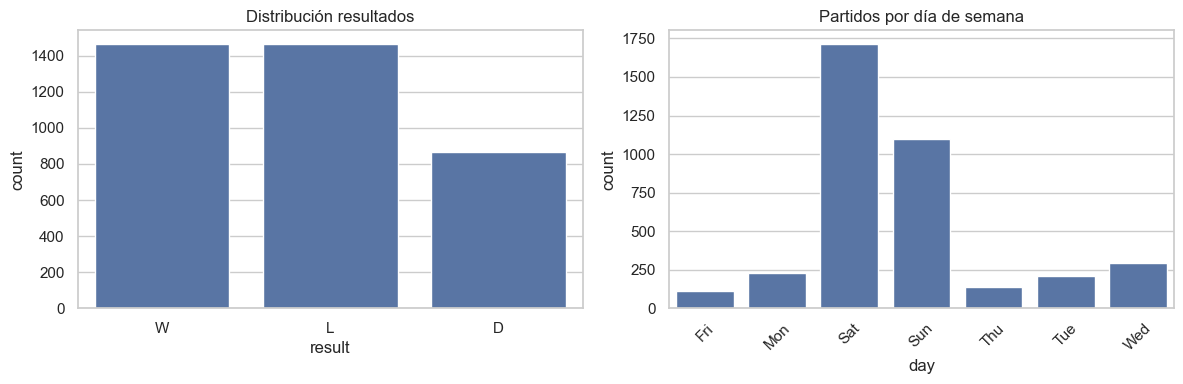

In [3]:
print(df['result'].value_counts())
print(df['team'].value_counts().head())
print(df['season'].value_counts())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='result')
plt.title('Distribución resultados')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='day', order=sorted(df['day'].unique()))
plt.title('Partidos por día de semana')
plt.xticks(rotation=45)
plt.tight_layout()

## Feature engineering

In [4]:
df['date'] = pd.to_datetime(df['date'])

# 1. Features de forma reciente (últimos 5 partidos)
df['form_points'] = df['result'].map({'W': 3, 'D': 1, 'L': 0})
df['form_points'] = df.groupby(['team'])['form_points'].transform(
    lambda x: x.rolling(5, min_periods=1).sum().shift(1)
)

# 2. Diferenciales de rendimiento
df['gf_diff'] = df['gf'] - df['ga']
df['xg_diff'] = df['xg'] - df['xga']
df['poss_diff'] = df['poss'] - (100 - df['poss'])  # vs rival implícito

# 3. Features de disparos
df['sh_eff'] = df['gf'] / (df['sh'] + 1)  # goles por disparo
df['sot_eff'] = df['gf'] / (df['sot'] + 1)

# 4. Posición en tabla (proxy)
df['table_pos'] = df.groupby(['season', 'team']).cumcount() + 1

# 5. Features de calendario
df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_home'] = 1  # todos son home en este dataset

df.head()

,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,opp formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,team,season,form_points,gf_diff,xg_diff,poss_diff,sh_eff,sot_eff,table_pos,dayofweek,month,is_home
0,2020-09-12,12:30,Premier League,Matchweek 1,Sat,Away,W,3,0,Fulham,1.9,0.1,54.0,NaN,Pierre-Emerick Aubameyang,3-4-3,4-2-3-1,Chris Kavanagh,Match Report,NaN,13.0,5.0,14.1,2.0,0,0,Arsenal,2021,NaN,3,1.8,8.0,0.214286,0.500000,1,5,9,1
1,2020-09-19,20:00,Premier League,Matchweek 2,Sat,Home,W,2,1,West Ham,1.1,2.0,62.0,NaN,Pierre-Emerick Aubameyang,3-4-3,5-4-1,Michael Oliver,Match Report,NaN,7.0,3.0,14.8,0.0,0,0,Arsenal,2021,3.0,1,-0.9,24.0,0.250000,0.500000,2,5,9,1
2,2020-09-28,20:00,Premier League,Matchweek 3,Mon,Away,L,1,3,Liverpool,1.3,2.7,34.0,NaN,Pierre-Emerick Aubameyang,3-4-3,4-3-3,Craig Pawson,Match Report,NaN,4.0,3.0,15.0,0.0,0,0,Arsenal,2021,6.0,-2,-1.4,-32.0,0.200000,0.250000,3,0,9,1
3,2020-10-04,14:00,Premier League,Matchweek 4,Sun,Home,W,2,1,Sheffield Utd,0.6,0.2,64.0,NaN,Pierre-Emerick Aubameyang,4-3-3,3-5-2,Lee Mason,Match Report,NaN,6.0,5.0,16.3,0.0,0,0,Arsenal,2021,6.0,1,0.4,28.0,0.285714,0.333333,4,6,10,1
4,2020-10-17,17:30,Premier League,Matchweek 5,Sat,Away,L,0,1,Manchester City,0.9,1.3,42.0,NaN,Pierre-Emerick Aubameyang,4-3-3,3-1-4-2,Chris Kavanagh,Match Report,NaN,11.0,3.0,18.4,2.0,0,0,Arsenal,2021,9.0,-1,-0.4,-16.0,0.000000,0.000000,5,5,10,1


In [5]:
# Target: 0=L, 1=D, 2=W
target_map = {'L': 0, 'D': 1, 'W': 2}
df['target'] = df['result'].map(target_map)

# Features numéricas
num_features = [
    'gf_diff', 'xg_diff', 'poss_diff', 'sh_eff', 'sot_eff',
    'form_points', 'table_pos', 'dayofweek', 'month'
]

# Features para modelar
X = df[num_features].fillna(0)
y = df['target']

print(X.shape, y.shape)
print(X.describe())

(3800, 9) (3800,)
           gf_diff       xg_diff    poss_diff       sh_eff     sot_eff  \
count  3800.000000  3.800000e+03  3800.000000  3800.000000  3800.00000   
mean      0.000000  1.121910e-17     0.001053     0.110411     0.26541   
std       1.962266  1.320138e+00    25.013942     0.100694     0.21838   
min      -9.000000 -6.400000e+00   -64.000000     0.000000     0.00000   
25%      -1.000000 -8.000000e-01   -18.000000     0.000000     0.00000   
50%       0.000000  0.000000e+00     0.000000     0.100000     0.25000   
75%       1.000000  8.000000e-01    18.000000     0.166667     0.40000   
max       9.000000  6.400000e+00    64.000000     1.000000     1.00000   

       form_points    table_pos    dayofweek        month  
count  3800.000000  3800.000000  3800.000000  3800.000000  
mean      6.814474    19.500000     4.428421     6.454211  
std       3.585389    10.967299     1.798959     3.846695  
min       0.000000     1.000000     0.000000     1.000000  
25%       4.000

## Visualizamos de variables

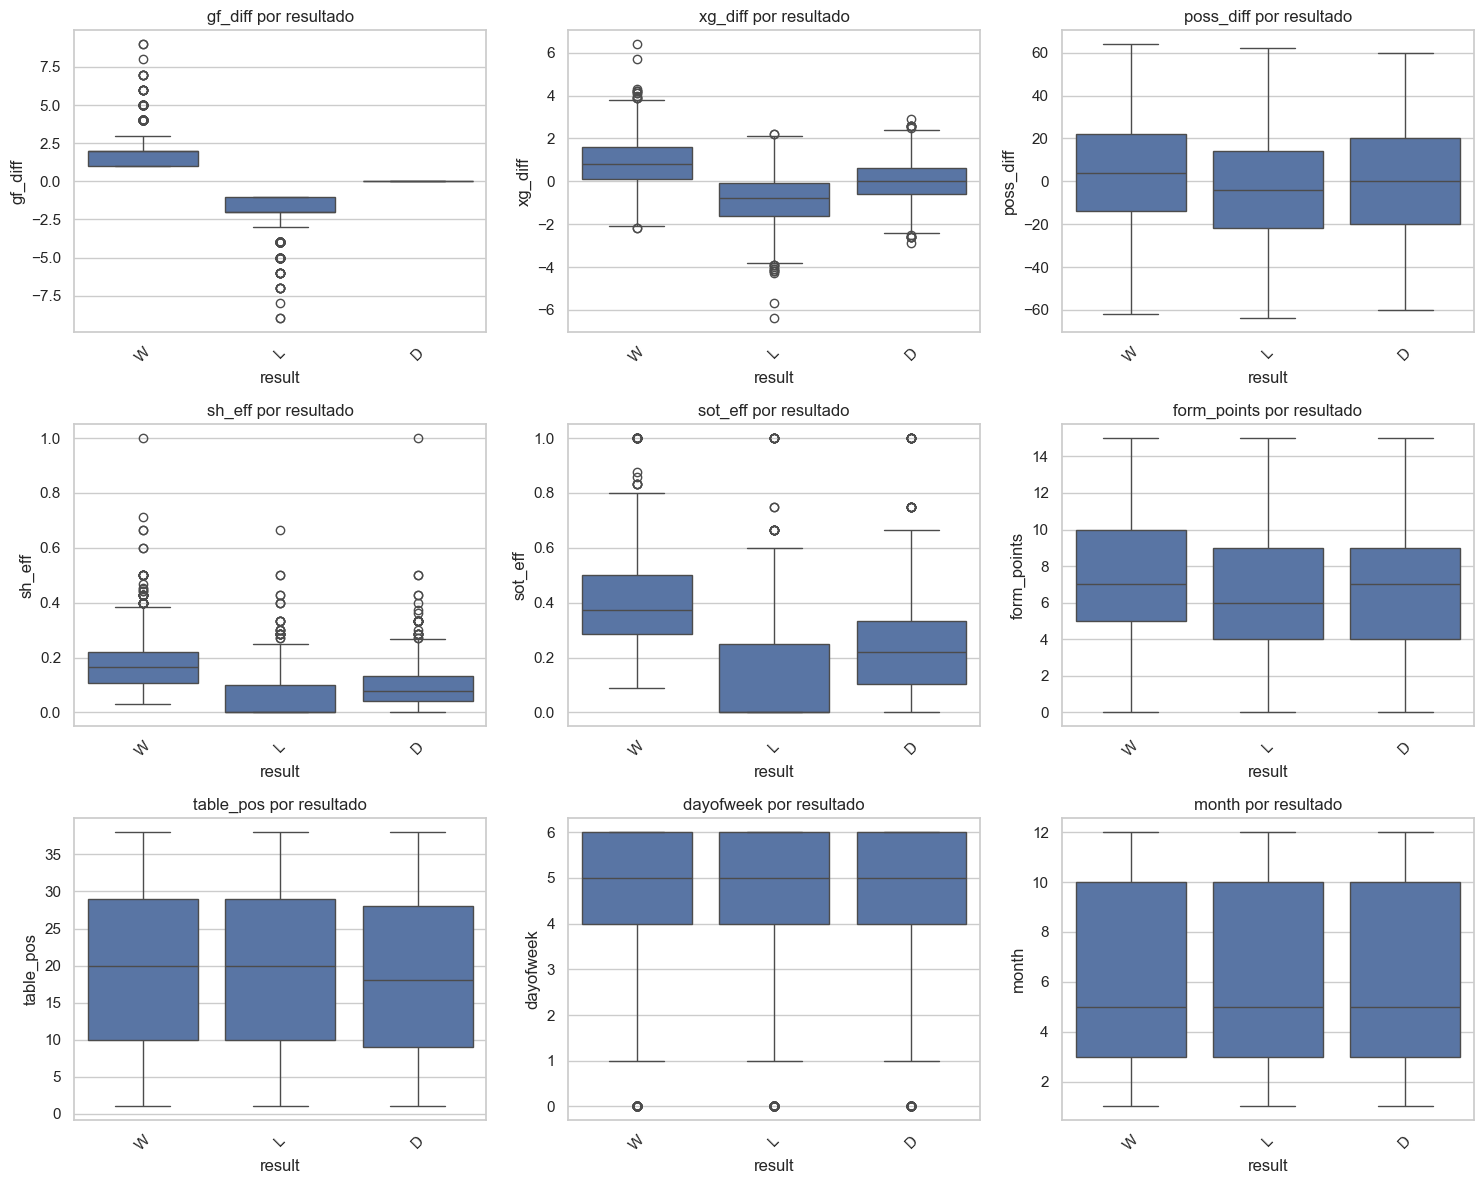

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='result', y=col, ax=axes[i])
    axes[i].set_title(f'{col} por resultado')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Baseline con RandomForest

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Loss', 'Draw', 'Win']))

              precision    recall  f1-score   support

        Loss       1.00      1.00      1.00       294
        Draw       1.00      1.00      1.00       173
         Win       1.00      1.00      1.00       293

    accuracy                           1.00       760
   macro avg       1.00      1.00      1.00       760
weighted avg       1.00      1.00      1.00       760



## Variables importantes

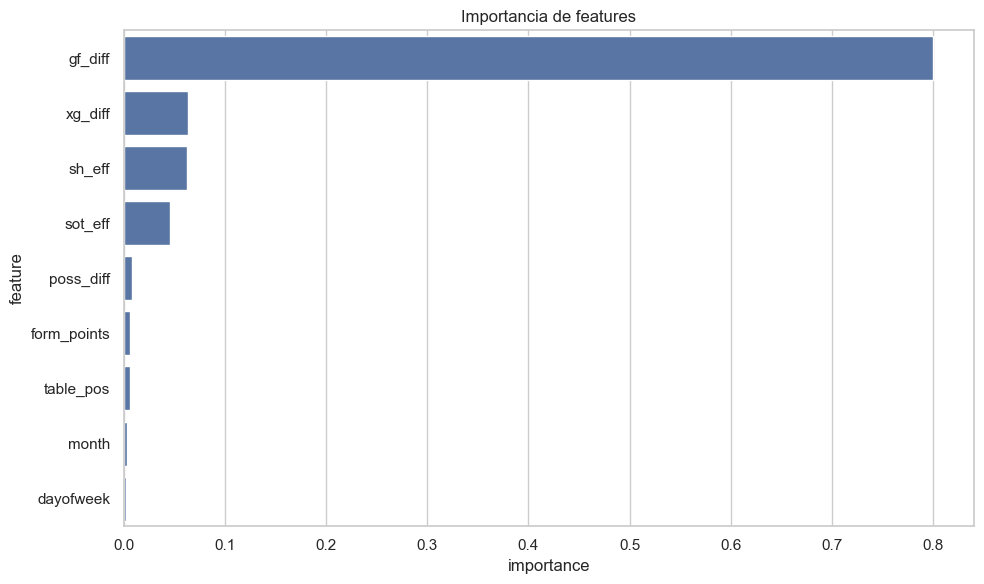

,feature,importance
0,gf_diff,0.800368
1,xg_diff,0.063549
3,sh_eff,0.062706
4,sot_eff,0.045601
2,poss_diff,0.008403
5,form_points,0.006694
6,table_pos,0.006629
8,month,0.003324
7,dayofweek,0.002726


In [8]:
importances = pd.DataFrame({
    'feature': num_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Importancia de features')
plt.tight_layout()
plt.show()

importances

## Matriz de confusión

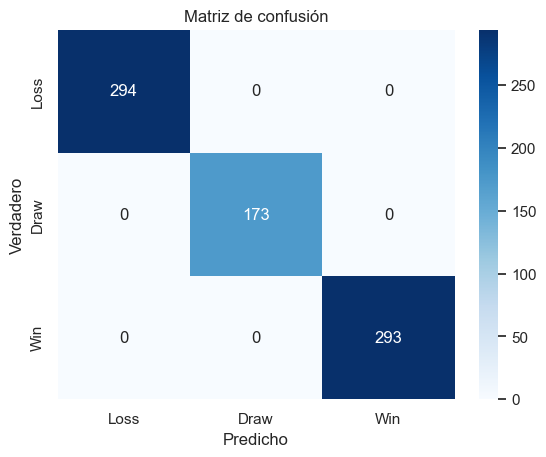

In [9]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss', 'Draw', 'Win'],
            yticklabels=['Loss', 'Draw', 'Win'])
plt.title('Matriz de confusión')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.show()

## Probar otro modelo

In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# 1. Gradient Boosting (mejor para ordinal)
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

scores = cross_val_score(gb, X, y, cv=5, scoring='accuracy')
print("GB CV Accuracy:", scores.mean(), "+/-", scores.std() * 2)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("\nGB Test Report:")
print(classification_report(y_test, y_pred_gb, target_names=['Loss', 'Draw', 'Win']))

GB CV Accuracy: 1.0 +/- 0.0

GB Test Report:
              precision    recall  f1-score   support

        Loss       1.00      1.00      1.00       294
        Draw       1.00      1.00      1.00       173
         Win       1.00      1.00      1.00       293

    accuracy                           1.00       760
   macro avg       1.00      1.00      1.00       760
weighted avg       1.00      1.00      1.00       760



## Ejemplo de uso

In [11]:
# Simular un partido futuro: ManU vs Arsenal
nuevo_partido = pd.DataFrame({
    'gf_diff': [0.2],      # ManU ligeramente mejor ataque
    'xg_diff': [0.3],      # mejor xG
    'poss_diff': [5],       # 5% más posesión
    'sh_eff': [0.12],      # eficiencia media
    'sot_eff': [0.25],
    'form_points': [9],    # buena forma reciente
    'table_pos': [4],      # 4º en tabla
    'dayofweek': [6],      # sábado
    'month': [3]           # marzo
})

pred = gb.predict_proba(nuevo_partido)[0]
print("Probabilidades: Loss {:.1%} | Draw {:.1%} | Win {:.1%}".format(*pred))
print("Predicción:", ['Loss', 'Draw', 'Win'][pred.argmax()])

Probabilidades: Loss 0.0% | Draw 100.0% | Win 0.0%
Predicción: Draw
